In [207]:
import os, glob, pandas as pd, matplotlib, matplotlib.pyplot as plt, xarray as xr, regionmask, cartopy, numpy as np, geopandas as gpd, datetime
from IPython.display import clear_output
from functools import reduce
import warnings; warnings.filterwarnings("ignore", category = FutureWarning)

from matplotlib.patches import Rectangle

xn,xx,yn,yx = [-130,-100,20,50]
mapproj = cartopy.crs.PlateCarree()
matplotlib.rcParams['savefig.bbox'] = "tight"

fpath = "/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/us-heatwave"



class MidpointNormalise(matplotlib.colors.Normalize):
    """ From: https://matplotlib.org/users/colormapnorms.html"""
    def __init__(self, vmin=None, vmax=None, midpoint=0, clip=False):
        self.midpoint = midpoint
        matplotlib.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...

        result, is_scalar = self.process_value(value)
        self.autoscale_None(result)

        vlargest = max( abs( self.vmax - self.midpoint ), abs( self.vmin - self.midpoint ) )
        x, y = [ self.midpoint - vlargest, self.midpoint, self.midpoint + vlargest], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))


def wrap_lon(ds):
    
    # method to wrap longitude from (0,360) to (-180,180)
    if "longitude" in ds.coords: ds = ds.rename(longitude = "lon", latitude = "lat")
    
    if ds.lon.max() > 180:
        ds["lon"] = (ds.lon.dims, (((ds.lon.values + 180) % 360) - 180), ds.lon.attrs)
        
    ds = ds.reindex({ "lon" : np.sort(ds.lon) })
    ds = ds.reindex({ "lat" : np.sort(ds.lat) })
    
    return ds

In [66]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmax_daily_extended_-130--100E_19-50N_-999-lastyear_su.nc -O data/era5_tmax_daily_extended_-130--100E_19-50N.nc

--2026-03-19 11:43:40--  https://climexp.knmi.nl/dyn_links/era5_tmax_daily_extended_-130--100E_19-50N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322236101 (307M) [application/x-netcdf]
Saving to: ‘data/era5_tmax_daily_extended_-130--100E_19-50N.nc’

data/era5_tmax_dail 100%[===================>] 307.31M   261MB/s    in 1.2s    

2026-03-19 11:43:43 (261 MB/s) - ‘data/era5_tmax_daily_extended_-130--100E_19-50N.nc’ saved [322236101/322236101]



In [ ]:
! wget https://climexp.knmi.nl/dyn_links/tmax_cpc_daily_-130--100E_20-50N_-999-lastyear_su.nc -O $fpath/tmax_cpc_daily_-130--100E_20-50N.nc

--2026-03-18 11:02:50--  https://climexp.knmi.nl/dyn_links/tmax_cpc_daily_-130--100E_20-50N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 142892114 (136M) [application/x-netcdf]
Saving to: ‘/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/us-heatwave//tmax_cpc_daily_-130--100E_20-50N.nc’

/rds/general/user/c 100%[===================>] 136.27M   240MB/s    in 0.6s    

2026-03-18 11:02:51 (240 MB/s) - ‘/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/us-heatwave//tmax_cpc_daily_-130--100E_20-50N.nc’ saved [142892114/142892114]



# Stations

In [4]:
# functions to download from GHCN-D
import sys; sys.path.append('/rds/general/user/cb2714/home/get-station-data'); 
from get_station_data import ghcnd
from get_station_data.util import nearest_stn

In [5]:
# import all metadata
stn_md = ghcnd.get_stn_metadata()

In [255]:
# identify stations of interest
stn_md = stn_md.loc[(stn_md.lon >= xn) & (stn_md.lon <= xx) & (stn_md.lat >= yn) & (stn_md.lat <= yx) & (stn_md.start_year <= 1900) & (stn_md.end_year >= 2026)]
stn_md.to_csv("station-metadata.csv", index = None)

## Loop over stations & download

In [ ]:
for i in range(len(stn_md)):
    print(i, "/", len(stn_md))
    r = stn_md.iloc[[i]]
    new_fnm = fpath+"/stations/stn_"+r.station.values[0]+".csv"
    if os.path.exists(new_fnm): continue

    # faster to download without flags, but no QA - should check this in final station selection
    ghcnd.get_data(r, element_types = ["TMAX"], include_flags = False).to_csv(new_fnm, index = None)
    clear_output(wait = False)
print("Done.")

81 / 209
Using 96 CPUs out of 128... 


  0%|          | 0/1 [00:00<?, ?it/s]

## Check latest date

In [186]:
latest_dates = {fnm.split("_")[-1][:-4]: pd.read_csv(fnm).dropna(axis = 0, how = "any").date.max() for fnm in glob.glob(fpath+"/stations/stn_*.csv")}

In [ ]:
latest_dates = pd.DataFrame(latest_dates, index = ["last_entry"]).transpose()

In [209]:
len(latest_dates.sort_values("last_entry").loc[latest_dates.last_entry >= "2026-03-16"])

39

## Get tx5x-mar for all stations

In [ ]:
stn_tx5x = []
for fnm in glob.glob(fpath+"/stations/stn_*.csv"):
    ts = pd.read_csv(fnm, parse_dates = ["date"], index_col = "date")[["value"]].dropna(axis = 0, how = "any").rename(columns = {"value" : fnm.split("_")[-1][:-4]})
    ts5 = ts.rolling(5).mean().loc[ts.index.month == 3]
    tx5x = ts5.resample("YS").max().where(ts5.resample("YS").count() == 31).dropna(axis = 0, how = "any")
    stn_tx5x.append(tx5x)

stn_tx5x = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), stn_tx5x)

tx5x_df = reduce(lambda left, right: pd.merge(left, right, left_index = True, right_index = True, how = 'outer'), stn_tx5x)
tx5x_df.to_csv("data/station_tx5x.csv")

## Map of trends in stations

In [202]:
df = pd.merge(pd.read_csv("station-trends.csv", index_col = 0).transpose(), pd.read_csv("station-metadata.csv", index_col = "station"), left_index = True, right_index = True)

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

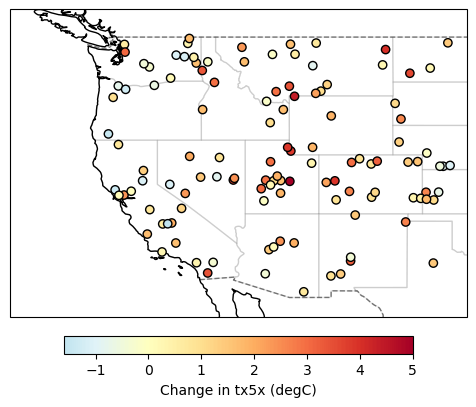

In [331]:
nc = 1
fig, ax = plt.subplots(ncols = nc, nrows = 1, figsize = (6,5), subplot_kw = {"projection" : mapproj, "extent" : (xn,xx+1,30,yx)})

cbar = ax.scatter(df.lon, df.lat, c = df.dI_abs, cmap = "RdYlBu_r", ec = "k", norm = MidpointNormalise(midpoint = 0, vmax = 5), zorder = 99)
plt.colorbar(cbar, label = "Change in tx5x (degC)", location = "bottom", shrink = 0.75, pad = 0.05)

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")

regionmask.defined_regions.natural_earth_v5_1_2.us_states_50.to_geodataframe().boundary.plot(ax = ax, color = "k", alpha = 0.1, lw = 1)

# Compile ERA5 data

In [49]:
ra = wrap_lon(xr.open_dataset("data/era5_tmax_daily_extended_-130--100E_19-50N.nc")).tmax.sel(lat = slice(19.5,None))

In [50]:
an = wrap_lon(xr.open_dataset("data/oper_tmax_2026-03-19_daily.nc").mx2t6.rename("tmax", longitude = "lon", latitude = "lat")).sel(lon = slice(xn,xx), lat = slice(yn,yx)) - 273.15

In [51]:
fc = wrap_lon(xr.open_dataset("data/forecast_tmax_2026-03-19_daily.nc").mx2t6.rename("tmax", longitude = "lon", latitude = "lat")).sel(lon = slice(xn,xx), lat = slice(yn,yx)) - 273.15

In [62]:
da = xr.concat([an, fc], "time")

sf = gpd.read_file("sf")

rm = regionmask.mask_geopandas(sf, da)
ts_upd = da.where(rm == 0, drop = True).mean(["lat", "lon"])
ts_upd = ts_upd.assign_coords(time = ts_upd.time.dt.floor("D"))

In [84]:
ts_org = xr.open_dataset("data/tmax-daily_era5.nc").tmax.sel(time = "2026")

Text(0.5, 1.0, 'Change in forecast')

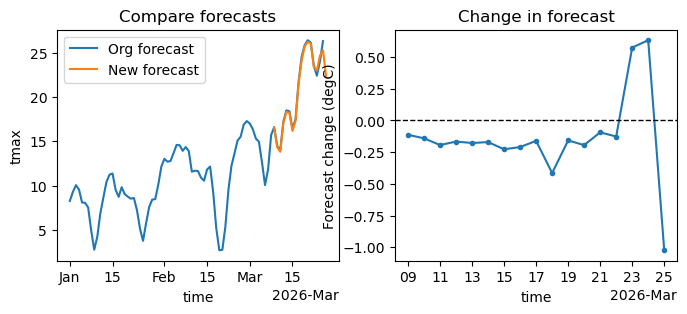

In [90]:
fig, axs = plt.subplots(ncols = 2, figsize = (8,3))

ax = axs[0]
ts_org.plot(ax = ax, label = "Org forecast")
ts_upd.plot(ax = ax, label = "New forecast")
ax.legend()
ax.set_title("Compare forecasts")


ax = axs[1]
(ts_upd - ts_org).plot(marker = ".")
ax.set_ylabel("Forecast change (degC)")
ax.axhline(0, color = "k", ls = "--", lw = 1)
ax.set_title("Change in forecast")

In [92]:
(ts_upd.rolling(time = 5).mean() - ts_org.rolling(time = 5).mean()).sel(time = "2026-03-22")

<xarray.DataArray 'tmax' ()> Size: 8B
array(-0.19725598)
Coordinates:
    time     datetime64[ns] 8B 2026-03-22

In [ ]:
ts_org.rolling(time = 5).mean().idxmax()

<xarray.DataArray 'time' ()> Size: 8B
array('2026-03-22T00:00:00.000000000', dtype='datetime64[ns]')

In [89]:
ts_upd.rolling(time = 5).mean().idxmax()

<xarray.DataArray 'time' ()> Size: 8B
array('2026-03-22T00:00:00.000000000', dtype='datetime64[ns]')

# Pointwise gridded trends

## Quick exploratory

In [ ]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmax_daily_na_extended_-130--100E_24.00-50N_-999-lastyear_su.nc -O $fpath/era5_tmax_daily_na_-130--100E_24.00-50N.nc

In [45]:
! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/igiss_al_gl_a_4yrlo.dat

--2026-03-18 12:03:32--  https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4778 (4.7K)
Saving to: ‘data/igiss_al_gl_a_4yrlo.dat’

data/igiss_al_gl_a_ 100%[===================>]   4.67K  --.-KB/s    in 0s      

2026-03-18 12:03:34 (41.6 MB/s) - ‘data/igiss_al_gl_a_4yrlo.dat’ saved [4778/4778]



In [349]:
# load daily data
da = xr.open_dataset(fpath+"/era5_tmax_daily_na_-130--100E_24.00-50N.nc").tmax#.sel(time = slice(None, "2025"))

# mask land only
rm = regionmask.defined_regions.natural_earth_v5_0_0.land_10.mask(da.lon, da.lat)
da = da.where(rm == 0, drop = True)

In [350]:
gmst = pd.read_table("data/igiss_al_gl_a_4yrlo.dat", comment = "#", sep = " +", engine = "python", header = None, names = ["year", "gmst"], index_col = "year")

In [351]:
# extract all candidate event definitions
defs = {"tx1x_ann" : da.resample(time = "YS").max(),
        "tx1x_mam" : da.sel(time = da.time.dt.month.isin([3,4,5])).resample(time = "YS").max(),
        "tx1x_mar" : da.groupby("time.month")[3].resample(time = "YS").max(),
        "tx5x_ann" : da.rolling(time = 5).mean().resample(time = "YS").max(),
        "tx5x_mam" : da.rolling(time = 5).mean().sel(time = da.time.dt.month.isin([3,4,5])).resample(time = "YS").max(),
        "tx5x_mar" : da.rolling(time = 5).mean().groupby("time.month")[3].resample(time = "YS").max()}

# fit linear trend
coeffs = xr.concat([r.assign_coords(time = gmst.loc[r.time.dt.year].gmst).polyfit("time", deg = 1).polyfit_coefficients.expand_dims(defn = [k]) for k, r in defs.items()], "defn")

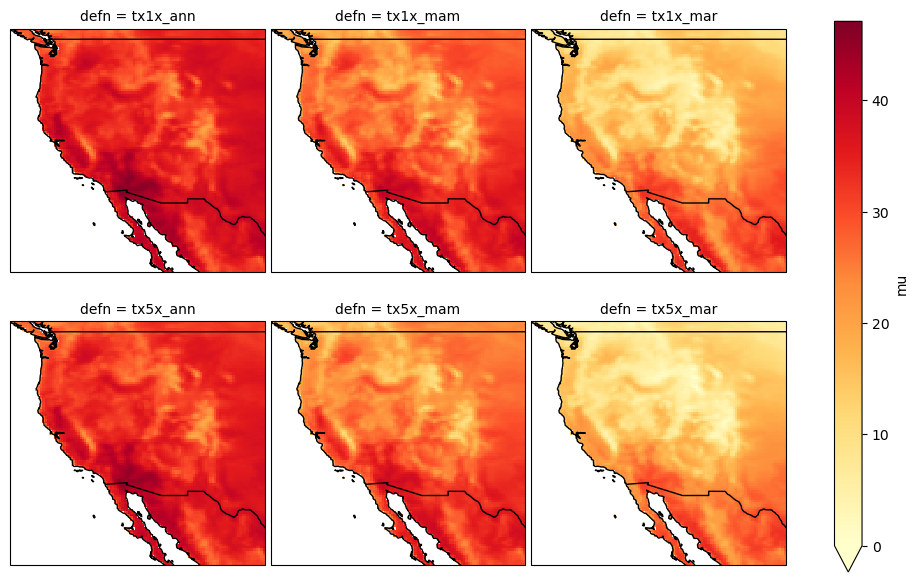

In [352]:
fig = coeffs.sel(degree = 0).plot(col = "defn", col_wrap = 3, cmap = "YlOrRd", subplot_kws = {"projection" : mapproj}, cbar_kwargs = {"label" : "mu"}, vmin = 0)

for ax in fig.axs.flatten():
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)

plt.savefig("fig/gridded-ltrend_mu_"+str(da.time.max().dt.strftime("%Y-%m-%d").values))

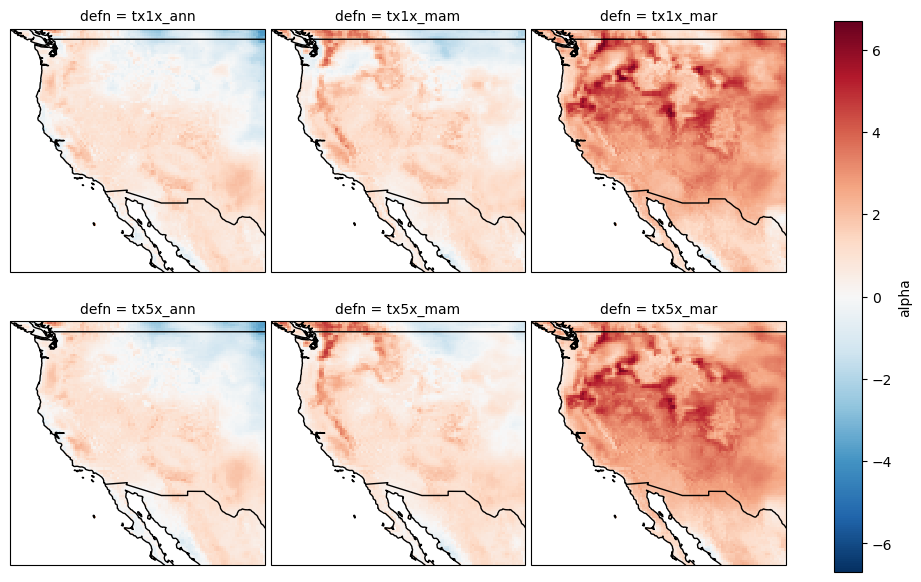

In [353]:
fig = coeffs.sel(degree = 1).plot(col = "defn", col_wrap = 3, cmap = "RdBu_r", subplot_kws = {"projection" : mapproj}, cbar_kwargs = {"label" : "alpha"})

for ax in fig.axs.flatten():
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)

plt.savefig("fig/gridded-ltrend_alpha_"+str(da.time.max().dt.strftime("%Y-%m-%d").values))

## Fit gridded GEV

### Flatten gridded data for trend fitting

In [ ]:
# make a new directory to store the data & results
! mkdir -p flattened; mkdir -p flattened-res

In [ ]:
# get event date
ts = xr.open_dataset("data/tmax-daily_era5.nc")
d = str(ts.rolling(time = 5).mean().groupby("time.month")[3].idxmax().tmax.dt.strftime("%Y-%m-%d").values)

In [ ]:
# load daily data
da = xr.open_dataset("data/era5_tmax_daily_na_-130--100E_30-50N.nc").tmax

# mask land only
rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da.lon, da.lat)
da = da.where(rm == 0, drop = True)

In [98]:
# daily event definition
da = da.rolling(time = 5).mean().groupby("time.month")[3]

# extract this year's event
ev = da.sel(time = d)

# get annual time series at each grid cell
da_ann = da.resample(time = "YS").max()

# merge event with  main time series (put event first so it's easier to identify)
da_ann = xr.concat([ev, da_ann], "time")

# relabel dates as years
da_ann = da_ann.assign_coords(time = da_ann.time.dt.year).rename(time = "year")

# set a file description that will be used to save all the data
fnm_root = "tx5x-mar-era5"

In [ ]:
# save the map for easier reconstruction later
da_ann.mean("year").to_netcdf("map-tmplt_"+fnm_root+".nc")

# flatten & convert to data.frame
df = da_ann.stack(xy = ["lat", "lon"]).dropna(dim = "xy", how = "all").to_pandas()

# save data.frame as .csv (split into chunks if really large)
ncols = 2500
if df.shape[1] > ncols:
    for i in range(int(np.ceil(df.shape[1] / ncols))):
        df.iloc[:,slice(i*ncols,(i+1)*ncols)].to_csv("flattened/"+fnm_root+"-flattened_"+str(i+1).rjust(2,"0")+".csv")
else:
    df.to_csv("flattened/"+fnm_root+"-flattened.csv")

### Fit trend in R

### Reshape fitted trends into maps

In [101]:
# function to reshape dataframe into map
def vec2map(x, mask):
    
    # reconstruct vector into map
    # create an empty map with NA in same cells as masks
    arr = mask.where(np.isnan(mask), 0)
    
    # get coordinates of non-empty cells
    px = np.argwhere(~np.isnan(mask.values))
    
    # Transfer vector values into non-empty cells in array
    if len(px) == len(x):
        for i in list(range(len(px))): arr[px[i,0], px[i,1]] = x[i]
        return arr
    else:
        print(str(len(x))+" values, but "+str(len(px))+" cells")
        return

In [102]:
# load target map showing original shape of data
tmplt = xr.open_dataset("map-tmplt_"+fnm_root+".nc").tmax

# load all the flattened results and compile into a single dataframe
df = pd.concat([pd.read_csv(fnm, index_col = 0) for fnm in sorted(glob.glob("flattened-res/"+fnm_root+"*.csv"))], axis = 1)

# reconstruct map
res = xr.merge([vec2map(df.loc[r], tmplt).rename(r) for r in df.index])

# replace infinite values with very high value
res["PR"] = res.PR.where(np.isfinite(res.PR), 1000).where(~np.isnan(res.PR))

# save
res.to_netcdf("gridded-trend_"+fnm_root+".nc")

## Maps

In [ ]:
res = xr.open_dataset("gridded-trend_tx5x-mar-era5_05res.nc")

In [125]:
stn = pd.merge(pd.read_csv("station-trends.csv", index_col = 0).transpose(), pd.read_csv("station-metadata.csv", index_col = "station"), left_index = True, right_index = True)

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


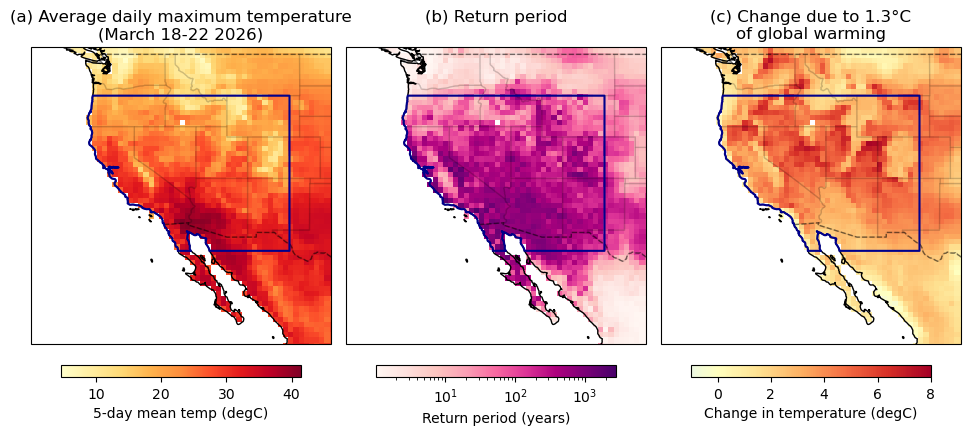

In [143]:
nc = 3; nr = 1
fig, axs = plt.subplots(ncols = nc, nrows = nr, figsize = (nc*4,nr*5.5), subplot_kw = {"projection" : mapproj, "extent" : (xn,xx-1,yn+1,yx-1)})
plt.subplots_adjust(wspace = 0.05)

cbar_kwargs = {"location" : "bottom", "shrink" : 0.8, "pad" : 0.05}

ax = axs[0]
res.event_magnitude.plot(ax = ax, cmap = "YlOrRd", cbar_kwargs = cbar_kwargs | {"label" : "5-day mean temp (degC)"})
ax.set_title("(a) Average daily maximum temperature\n(March 18-22 2026)")

ax = axs[1]
res.return_period.plot(ax = ax, norm = matplotlib.colors.LogNorm(), cmap = "RdPu", cbar_kwargs = cbar_kwargs | {"label" : "Return period (years)"})
ax.set_title("(b) Return period\n")

ax = axs[2]
res.dI_abs.plot(norm = MidpointNormalise(midpoint = 0, vmin = -1, vmax = 8), cmap = "RdYlBu_r", cbar_kwargs = cbar_kwargs | {"label" : "Change in temperature (degC)"})
ax.set_title("(c) Change due to 1.3°C\nof global warming")
# ax.scatter(stn.lon, stn.lat, c = stn.dI_abs, cmap = "RdYlBu_r", ec = "k", norm = MidpointNormalise(midpoint = 0, vmin = -1, vmax = 8), zorder = 99)


for ax in axs:
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
    regionmask.defined_regions.natural_earth_v5_1_2.us_states_50.to_geodataframe().boundary.plot(ax = ax, color = "k", alpha = 0.1, lw = 1)
    sf.boundary.plot(ax = ax, color = "darkblue")

plt.savefig("fig/gridded-trends.png")

# Get time series


In [37]:
! wget https://climexp.knmi.nl/dyn_links/era5_tmax_daily_na_extended_-130--100E_30.00-50N_-999-lastyear_su.nc -O data/era5_tmax_daily_na_-130--100E_30-50N.nc

--2026-03-19 11:12:48--  https://climexp.knmi.nl/dyn_links/era5_tmax_daily_na_extended_-130--100E_30.00-50N_-999-lastyear_su.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 761838373 (727M) [application/x-netcdf]
Saving to: ‘data/era5_tmax_daily_na_-130--100E_30-50N.nc’

data/era5_tmax_dail 100%[===================>] 726.54M   274MB/s    in 2.7s    

2026-03-19 11:12:50 (274 MB/s) - ‘data/era5_tmax_daily_na_-130--100E_30-50N.nc’ saved [761838373/761838373]



In [49]:
da = xr.open_dataset("data/era5_tmax_daily_na_-130--100E_30-50N.nc")

sf = gpd.read_file("sf")

rm = regionmask.mask_geopandas(sf, da)

ts = da.where(rm == 0, drop = True).mean(["lat", "lon"])
tx5x_m = ts.rolling(time = 5).mean().groupby("time.month")[3].resample(time = "YS").max()
tx5x_m = tx5x_m.assign_coords(time = tx5x_m.time.dt.year).rename(time = "year")
tx5x_m.to_dataframe().to_csv("tx5x-clair_era5.csv")

ts.to_netcdf("data/tmax-daily_era5.nc")

In [45]:
ts.rolling(time = 5).mean().sel(time = "2026-03").tmax.idxmax()

<xarray.DataArray 'time' ()> Size: 8B
array('2026-03-22T00:00:00.000000000', dtype='datetime64[ns]')

In [39]:
da = xr.open_dataset(fpath+"/tmax_cpc_daily_-130--100E_20-50N.nc")

sf = gpd.read_file("sf")

rm = regionmask.mask_geopandas(sf, da)

ts = da.where(rm == 0, drop = True).mean(["lat", "lon"])
tx5x_m = ts.rolling(time = 5).mean().groupby("time.month")[3].resample(time = "YS").max()
tx5x_m = tx5x_m.assign_coords(time = tx5x_m.time.dt.year).rename(time = "year")
tx5x_m.to_dataframe().to_csv("tx5x-clair_cpc.csv")

ts.to_netcdf("data/tmax-daily_cpc.nc")

# Event map

In [88]:
da = xr.open_dataset("data/era5_tmax_daily_extended_-130--100E_19-50N.nc").tmax

rm = regionmask.defined_regions.natural_earth_v5_1_2.land_50.mask(da.lon, da.lat)
da = da.where(rm == 0, drop = True)

In [ ]:
da_ev = da.sel(time = "2026").rolling(time = 5).mean().sel(time = "2026-03-22")
da_clim = da.sel(time = slice("1991","2020")).groupby("time.month")[3].mean("time")

da_anom = da_ev - da_clim

In [128]:
states = regionmask.defined_regions.natural_earth_v5_1_2.us_states_50.to_geodataframe().clip((xn,yn,xx,yx))

In [203]:
ts = xr.open_dataset("data/tmax-daily_era5.nc").tmax.to_dataframe()

hist = slice("1950", "1980")
pres = slice("1995", "2025")
fc_start = "2026-03-18"


days = pd.date_range(start = "2026-01-01", end = "2027-01-01")
labelticks = [i+1 for i in range(len(days)) if (days[i].day) == 15]
labels = [days[i].strftime("%b")[0] for i in range(len(days)) if (days[i].day) == 15]

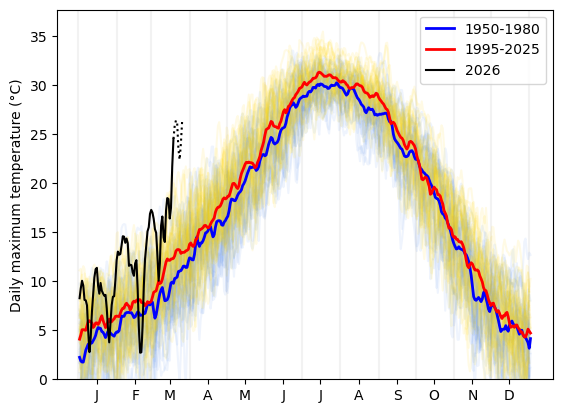

In [204]:
fig, ax = plt.subplots()



/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.5, 1.0, '(b) Seasonal cycle of\ndaily maximum temperatures')

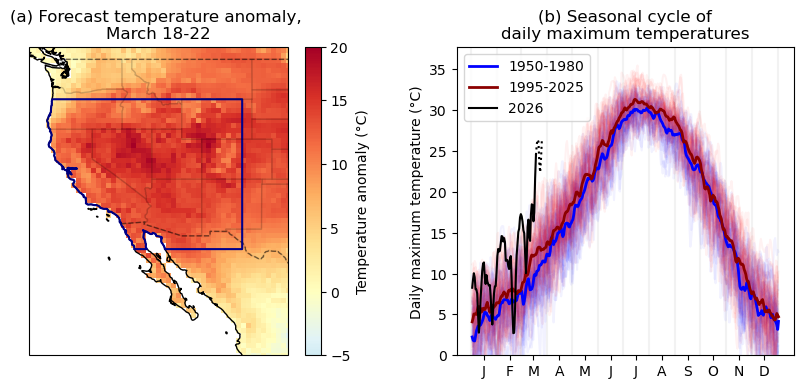

In [213]:
fig, axs = plt.subplots(ncols = 2, figsize = (10,4), dpi = 100)
plt.subplots_adjust(wspace = 0.3)

axs[0].set_axis_off()

ax = fig.add_subplot(121, projection = mapproj, extent = (da_anom.lon.min(), da_anom.lon.max(), da_anom.lat.min(), da_anom.lat.max()-0.1))

da_anom.plot(ax = ax, cmap = "RdYlBu_r", norm = MidpointNormalise(midpoint = 0, vmin = -5),
                  cbar_kwargs = {"label" : "Temperature anomaly (°C)"})

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
sf.boundary.plot(ax = ax, color = "darkblue")
states.boundary.plot(ax = ax, color = "k", alpha = 0.1, lw = 1)
ax.set_title("")

ax.set_title("(a) Forecast temperature anomaly, \nMarch 18-22")



ax = axs[1]
ts.loc[hist].groupby(ts.loc[hist].index.dayofyear).mean().plot(ax = ax, color = "blue", lw = 2, label = hist.start+"-"+hist.stop, zorder = 99)
ts.loc[pres].groupby(ts.loc[pres].index.dayofyear).mean().plot(ax = ax, color = "darkred", lw = 2, label = pres.start+"-"+pres.stop, zorder = 99)

ts.loc[slice("2026-01", fc_start)].groupby(ts.loc[slice("2026-01", fc_start)].index.dayofyear).mean().plot(ax = ax, color = "k", zorder = 99)
ts.loc[slice(fc_start, None)].groupby(ts.loc[slice(fc_start, None)].index.dayofyear).mean().plot(ax = ax, color = "k", ls = ":", zorder = 99)

for y in range(int(hist.start), int(hist.stop)+1): 
    ax.plot(ts.loc[str(y)].index.dayofyear, ts.loc[str(y)], color = "blue", alpha = 0.05, label = "_")

for y in range(int(pres.start), int(pres.stop)+1): 
    ax.plot(ts.loc[str(y)].index.dayofyear, ts.loc[str(y)], color = "red", alpha = 0.05, label = "_")

ax.set_xticks(labelticks)
ax.set_xticklabels(labels)
[ax.axvline(x, color = "k", alpha = 0.05) for x in range(len(days)) if (days[x].day) == 1]

ax.set_xlabel("")
ax.set_ylabel("Daily maximum temperature (°C)")
ax.set_ylim(0,None)

ax.legend([hist.start+"-"+hist.stop, pres.start+"-"+pres.stop, "2026"])

ax.set_title("(b) Seasonal cycle of\ndaily maximum temperatures")

# Trends per calendar month

In [204]:
ts = xr.open_dataset("data/tmax-daily_era5.nc").tmax.to_dataframe()
tx5x_monthly = ts.rolling(5).mean().resample("MS").max()

tx5x_monthly.to_csv("tx5x-monthly_era5.csv")
ts.resample("MS").mean().to_csv("tmax-monthly_era5.csv")

# actual models fitted in R

In [205]:
df2 = pd.read_csv("alpha_tx5x_era5.csv", index_col = 0)
df1 = pd.read_csv("alpha_tmax_era5.csv", index_col = 0)

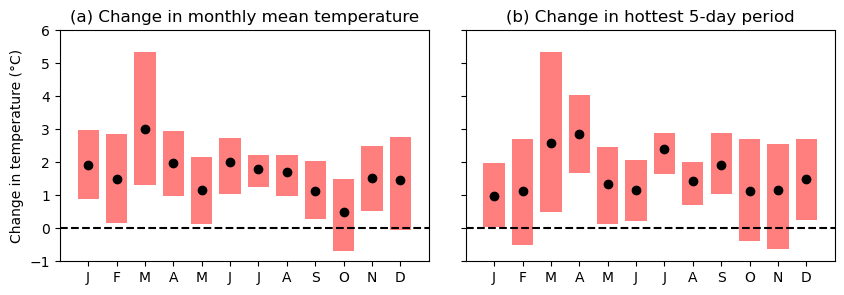

In [206]:
nc = 2
fig, axs = plt.subplots(ncols = nc, figsize = (nc*5, 3), dpi = 100, sharey = True)
plt.subplots_adjust(wspace = 0.1)

w = 0.75
h = 0.1

for i in range(2):
    ax = axs[i]
    df = [df1, df2][i]
    
    for m in range(12):
        r = df.iloc[m]
        ax.add_patch(Rectangle(xy = (m-w/2, r["X2.5."]), width = w, height = r["X97.5."] - r["X2.5."], facecolor = "red", alpha = 0.5))
        ax.scatter(m, r["est"], color = "k")
    
    ax.set_ylim(np.floor(df.values.flatten().min()), np.ceil(df.values.flatten().max()))
    ax.set_xlim(-1,12)
    
    
    ax.set_xticks(range(12))
    ax.set_xticklabels([datetime.datetime(2026,m,1).strftime("%b")[:1] for m in range(1,13)])
    
    ax.axhline(0, color = "k", ls = "--")

axs[0].set_ylabel("Change in temperature (°C)")
axs[0].set_title("(a) Change in monthly mean temperature")
axs[1].set_title("(b) Change in hottest 5-day period")

plt.savefig("fig/monthly-temp-change.png")

In [208]:
xr.open_dataset("data/oper_tmax_2026-03-18_daily.nc")

<xarray.Dataset> Size: 21MB
Dimensions:    (time: 10, bnds: 2, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 80B 2026-03-08T12:00:00 ... 2026-03-17T1...
  * longitude  (longitude) float32 3kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 160B ...
    mx2t6      (time, latitude, longitude) float64 21MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Mar 18 08:01:38 2026: cdo -O -r -f nc4 -s -daymax -shif...
    frequency:    day
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...